## Data Science Test

## Data Collection

### MySQL Database

### marks - 30

##### Q1. Perform the following queries on the below questions:

1. Create a database named SchoolDB
2. Use the database SchoolDB
3. Create a table named Students with the following fields: StudentID, FirstName, LastName, DOB (Date of Birth), and Gender
4. Create a table named Courses with the following fields: CourseID, CourseName, and Credits
5. Create a table named Enrollments with fields: EnrollmentID, StudentID, CourseID, and Grade. Ensure StudentID and CourseID are 6. 7.  foreign keys referencing the Students and Courses tables, respectively.
6. Insert five students into the Students table and five courses into the Courses table.
7. Enroll four students in various courses and assign grades.
8. Write a query to display all students’ first names, last names, and dates of birth.
9. Retrieve all the courses where students are enrolled. Display course names and student names (first and last).

### Install MySQL and Import Library

pip install mysql-connector-python

In [1]:
import mysql.connector

### Connect to MySQL

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    port=3306,
    password=''
)

cursor = conn.cursor()

print("Connected Successfully!")

Connected Successfully!


### Create Database (Question 1)

In [3]:
cursor.execute("CREATE DATABASE IF NOT EXISTS SchoolDB")

print("Database Created Successfully")

Database Created Successfully


### Use Database (Question 2)

In [4]:
cursor.execute("USE SchoolDB")

print("Database Selected")

Database Selected


### Create Students Table (Question 3)

In [5]:
query = """
CREATE TABLE IF NOT EXISTS Students(
    StudentID INT PRIMARY KEY,
    FirstName VARCHAR(50),
    LastName VARCHAR(50),
    DOB DATE,
    Gender VARCHAR(10)
)
"""

cursor.execute(query)

print("Students Table Created")

Students Table Created


### Create Courses Table (Question 4)

In [6]:
query = """
CREATE TABLE IF NOT EXISTS Courses(
    CourseID INT PRIMARY KEY,
    CourseName VARCHAR(100),
    Credits INT
)
"""

cursor.execute(query)

print("Courses Table Created")

Courses Table Created


### Create Enrollments Table (Question 5)

In [7]:
query = """
CREATE TABLE IF NOT EXISTS Enrollments(
    EnrollmentID INT PRIMARY KEY,
    StudentID INT,
    CourseID INT,
    Grade CHAR(2),

    FOREIGN KEY(StudentID)
    REFERENCES Students(StudentID),

    FOREIGN KEY(CourseID)
    REFERENCES Courses(CourseID)
)
"""

cursor.execute(query)

print("Enrollments Table Created")

Enrollments Table Created


### Insert Five Students (Question 6)

In [10]:
students = [

(1,"Mayank","Kumar","2004-08-15","Male"),
(2,"Rahul","Sharma","2003-05-20","Male"),
(3,"Priya","Singh","2004-02-11","Female"),
(4,"Aman","Verma","2003-10-25","Male"),
(5,"Neha","Gupta","2004-12-01","Female")

]

query = """
INSERT INTO Students
(StudentID,FirstName,LastName,DOB,Gender)
VALUES(%s,%s,%s,%s,%s)
"""

cursor.executemany(query, students)

conn.commit()

print("Students Inserted Successfully")

Students Inserted Successfully


### Insert Five Courses (Question 6)

In [13]:
courses = [

(101,"Python Programming",4),
(102,"Database Management",3),
(103,"Data Science",4),
(104,"Machine Learning",4),
(105,"Cloud Computing",3)

]

query = """
INSERT INTO Courses
VALUES(%s,%s,%s)
"""

cursor.executemany(query, courses)

conn.commit()

print("Courses Inserted Successfully")

Courses Inserted Successfully


### Enroll Students (Question 7)

In [14]:
enrollments = [

(1,1,101,'A'),
(2,2,102,'B'),
(3,3,103,'A'),
(4,4,101,'A')

]

query = """
INSERT INTO Enrollments
VALUES(%s,%s,%s,%s)
"""

cursor.executemany(query, enrollments)

conn.commit()

print("Enrollments Added")

Enrollments Added


### Display All Students (Question 8)

In [15]:
query = """
SELECT FirstName, LastName, DOB
FROM Students
"""

cursor.execute(query)

result = cursor.fetchall()

print("Student Details\n")

for row in result:
    print(row)

Student Details

('Mayank', 'Kumar', datetime.date(2004, 8, 15))
('Rahul', 'Sharma', datetime.date(2003, 5, 20))
('Priya', 'Singh', datetime.date(2004, 2, 11))
('Aman', 'Verma', datetime.date(2003, 10, 25))
('Neha', 'Gupta', datetime.date(2004, 12, 1))


### Display Student Name and Course Name (Question 9)

In [16]:
query = """
SELECT
Students.FirstName,
Students.LastName,
Courses.CourseName

FROM Enrollments

INNER JOIN Students
ON Enrollments.StudentID = Students.StudentID

INNER JOIN Courses
ON Enrollments.CourseID = Courses.CourseID
"""

cursor.execute(query)

result = cursor.fetchall()

print("Student Enrollments\n")

for row in result:
    print(row)

Student Enrollments

('Mayank', 'Kumar', 'Python Programming')
('Rahul', 'Sharma', 'Database Management')
('Priya', 'Singh', 'Data Science')
('Aman', 'Verma', 'Python Programming')


##  Web Scraping

### marks - 20

https://www.worldometers.info/coronavirus/

#### Q2. Use the above mentioned url and scrape the data from table and store the data into a csv file

In [17]:
import requests

url = "https://www.worldometers.info/coronavirus/"

response = requests.get(url)

print(response.status_code)

200


In [18]:
with open("Coronavirus.html", "w", encoding="utf-8") as f:
    f.write(response.text)

print("HTML saved")

HTML saved


In [19]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)

COVID - Coronavirus Statistics - Worldometer


In [21]:
table = soup.find("table")
print(table)

<table class="table table-bordered table-hover main_table_countries" id="main_table_countries_today" style="width:100%;margin-top: 0px !important;display:none;">
<thead>
<tr>
<th width="1%">#</th>
<th width="100">Country,<br/>Other</th>
<th width="20">Total<br/>Cases</th>
<th width="30">New<br/>Cases</th>
<th width="30">Total<br/>Deaths</th>
<th width="30">New<br/>Deaths</th>
<th width="30">Total<br/>Recovered</th>
<th width="30">New<br/>Recovered</th>
<th width="30">Active<br/>Cases</th>
<th width="30">Serious,<br/>Critical</th>
<th width="30">Tot Cases/<br/>1M pop</th>
<th width="30">Deaths/<br/>1M pop</th>
<th width="30">Total<br/>Tests</th>
<th width="30">Tests/<br/>
<nobr>1M pop</nobr>
</th>
<th width="30">Population</th>
<th style="display:none" width="30">Continent</th>
<th width="30">1 Case<br/>every X ppl</th><th width="30">1 Death<br/>every X ppl</th><th width="30">1 Test<br/>every X ppl</th>
<th width="30">New Cases/1M pop</th>
<th width="30">New Deaths/1M pop</th>
<th width

In [22]:
headers = []

for th in table.find("thead").find_all("th"):
    headers.append(th.text.strip())

print(headers)

['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/\n1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']


In [23]:
rows = []

tbody = table.find("tbody")

for tr in tbody.find_all("tr"):
    cols = tr.find_all("td")

    row = [col.text.strip() for col in cols]

    rows.append(row)

print(rows)

[['', 'North America', '131,889,132', '', '1,695,941', '', '127,665,129', '+350', '2,528,062', '6,095', '', '', '', '', '', 'North America', '', '', '', '', '', ''], ['', 'Asia', '221,500,265', '', '1,553,662', '', '205,673,091', '', '14,273,512', '14,733', '', '', '', '', '', 'Asia', '', '', '', '', '', ''], ['', 'Europe', '253,406,198', '', '2,101,824', '', '248,754,104', '+474', '2,550,270', '4,453', '', '', '', '', '', 'Europe', '', '', '', '', '', ''], ['', 'South America', '70,200,879', '', '1,367,332', '', '66,683,585', '', '2,149,962', '8,953', '', '', '', '', '', 'South America', '', '', '', '', '', ''], ['', 'Oceania', '14,895,771', '', '33,015', '', '14,752,388', '', '110,368', '31', '', '', '', '', '', 'Australia/Oceania', '', '', '', '', '', ''], ['', 'Africa', '12,860,924', '', '258,892', '', '12,090,808', '', '511,224', '529', '', '', '', '', '', 'Africa', '', '', '', '', '', ''], ['', '', '721', '', '15', '', '706', '', '0', '0', '', '', '', '', '', '', '', '', '', '', 

In [24]:
import pandas as pd

df = pd.DataFrame(rows, columns=headers)
print(df.head())

  #  Country,Other   TotalCases NewCases TotalDeaths NewDeaths TotalRecovered  \
0    North America  131,889,132            1,695,941              127,665,129   
1             Asia  221,500,265            1,553,662              205,673,091   
2           Europe  253,406,198            2,101,824              248,754,104   
3    South America   70,200,879            1,367,332               66,683,585   
4          Oceania   14,895,771               33,015               14,752,388   

  NewRecovered ActiveCases Serious,Critical  ... TotalTests Tests/\n1M pop  \
0         +350   2,528,062            6,095  ...                             
1               14,273,512           14,733  ...                             
2         +474   2,550,270            4,453  ...                             
3                2,149,962            8,953  ...                             
4                  110,368               31  ...                             

  Population          Continent 1 Caseevery 

In [25]:
df.to_csv("Coronavirus_data.csv", index=False)

print("Data saved successfully!")

Data saved successfully!


## API

### marks - 10

#### Q3. What is API? Explain the working of API.
#### Q4. What are HTTP methods? Explain.
#### Q5. How can you make an API request using the requests library in Python? Provide an example of making a GET request.
#### Q6. Explain the difference between REST and SOAP APIs.

### Q3. What is API? Explain the working of API.

What is an API?

API (Application Programming Interface) is a set of rules that allows two software applications to communicate and exchange data with each other.

An API acts as a bridge between the client (user/application) and the server.

Step-by-Step Working
1. The user sends a request through an application.
2. The application sends the request to the API.
3. The API forwards the request to the server.
4. The server processes the request.
5. The server retrieves data from the database.
6. The API returns the response (usually JSON).
7. The application displays the result.

### Q4. What are HTTP methods? Explain.

HTTP methods define the action that the client wants the server to perform.

The most common HTTP methods are:
1. GET – Used to retrieve (fetch) data from the server.
2. POST – Used to send or add new data to the server.
3. PUT – Used to update existing data completely.
4. DELETE – Used to remove data from the server.

GET → Example:
GET /students
Returns all students.

POST → Example:
POST /students
Creates a new student.

PUT → Example:
PUT /students/1
Updates all information for student 1.

DELETE →Example:
DELETE /students/1
Deletes student 1.

### Q5. How can you make an API request using the requests library in Python? Provide an example of making a GET request.

Requests Library:
The requests library is a Python package used to send HTTP requests to APIs.

Steps
1. Install (pip install requests)
2. Import the requests library.
3. Write the API URL.
4. Send a GET request using requests.get().
5. Print the response.

In [26]:
# Example of using requests to fetch JSON data from an API
import requests

url = "https://jsonplaceholder.typicode.com/posts/1"

response = requests.get(url)

print("Status Code:", response.status_code)

print(response.json())

Status Code: 200
{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


In [27]:
import requests

url = "https://api.github.com"

response = requests.get(url)

print(response.status_code)
print(response.json())

200
{'current_user_url': 'https://api.github.com/user', 'current_user_authorizations_html_url': 'https://github.com/settings/connections/applications{/client_id}', 'authorizations_url': 'https://api.github.com/authorizations', 'code_search_url': 'https://api.github.com/search/code?q={query}{&page,per_page,sort,order}', 'commit_search_url': 'https://api.github.com/search/commits?q={query}{&page,per_page,sort,order}', 'emails_url': 'https://api.github.com/user/emails', 'emojis_url': 'https://api.github.com/emojis', 'events_url': 'https://api.github.com/events', 'feeds_url': 'https://api.github.com/feeds', 'followers_url': 'https://api.github.com/user/followers', 'following_url': 'https://api.github.com/user/following{/target}', 'gists_url': 'https://api.github.com/gists{/gist_id}', 'hub_url': 'https://api.github.com/hub', 'issue_search_url': 'https://api.github.com/search/issues?q={query}{&page,per_page,sort,order}', 'issues_url': 'https://api.github.com/issues', 'keys_url': 'https://api

### Q6. Explain the difference between REST and SOAP APIs.

| Feature     | REST API                        | SOAP API                      |
| ----------- | ------------------------------- | ----------------------------- |
| Full Form   | Representational State Transfer | Simple Object Access Protocol |
| Type        | Architectural style             | Communication protocol        |
| Data Format | JSON, XML, HTML, Text           | XML only                      |
| Speed       | Faster                          | Slower                        |
| Complexity  | Simple                          | Complex                       |
| Bandwidth   | Uses less bandwidth             | Uses more bandwidth           |
| Security    | HTTPS, OAuth, JWT               | WS-Security (high security)   |
| Flexibility | High                            | Low                           |
| Learning    | Easy                            | Difficult                     |
| Performance | Better                          | Lower compared to REST        |

## Statistics

### Marks - 50

Q1.You are given the following dataset of monthly salaries (in dollars) of 15 employees:

[2500, 3000, 3200, 2800, 2700, 2900, 3100, 2600, 2750, 3500, 4000, 3600, 3200, 3300, 3400]

Calculate the mean salary. Find the median salary. Determine the mode of the dataset.

Q2.Using the same dataset from Question 1, calculate the following:

Range of the salaries.
Variance of the salaries.
Standard deviation of the salaries.
Explain what these statistics tell you about the distribution of the salaries.

Q3.Given the dataset of salaries from Question 1:

Calculate the first quartile (Q1), second quartile (Q2/median), and third quartile (Q3). Compute the Interquartile Range (IQR).

Q4.You are given the following ages (in years) of 20 employees:

[23, 26, 31, 35, 37, 42, 28, 33, 29, 34, 38, 40, 32, 30, 36, 27, 45, 39, 41, 43]

Create a grouped frequency table for the data. You can use either inclusive or exclusive method.

Q5.A survey is conducted to study the heights of a group of students. The data is collected and follows a normal distribution with a mean height of 160 cm and a standard deviation of 8 cm.

a) What percentage of students have heights between 152 cm and 168 cm?
b) If 200 students are surveyed, how many would you expect to have heights above 176 cm?

### Q1. Mean, Median and Mode

In [28]:
# Import libraries
import statistics

# Salary dataset
salaries = [2500, 3000, 3200, 2800, 2700,
            2900, 3100, 2600, 2750, 3500,
            4000, 3600, 3200, 3300, 3400]

# Mean
mean_salary = statistics.mean(salaries)

# Median
median_salary = statistics.median(salaries)

# Mode
mode_salary = statistics.mode(salaries)

print("Mean Salary =", mean_salary)
print("Median Salary =", median_salary)
print("Mode Salary =", mode_salary)

Mean Salary = 3103.3333333333335
Median Salary = 3100
Mode Salary = 3200


### Q2. Range, Variance and Standard Deviation

In [29]:
# Range
salary_range = max(salaries) - min(salaries)

# Sample Variance
variance = statistics.variance(salaries)

# Sample Standard Deviation
std_dev = statistics.stdev(salaries)

print("Range =", salary_range)
print("Variance =", variance)
print("Standard Deviation =", std_dev)

Range = 1500
Variance = 171595.2380952381
Standard Deviation = 414.24055583107514


In [30]:
print("\nInterpretation:")
print("1. Range shows the difference between highest and lowest salary.")
print("2. Variance measures how spread out the salaries are.")
print("3. Standard deviation shows the average distance of salaries from the mean.")


Interpretation:
1. Range shows the difference between highest and lowest salary.
2. Variance measures how spread out the salaries are.
3. Standard deviation shows the average distance of salaries from the mean.


### Q3. Quartiles and IQR

In [31]:
# Median (Q2)
Q2 = statistics.median(salaries)

# Lower half
lower = salaries[:7]

# Upper half
upper = salaries[8:]

Q1 = statistics.median(lower)
Q3 = statistics.median(upper)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q2 =", Q2)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 2900
Q2 = 3100
Q3 = 3400
IQR = 500


### Q4. Grouped Frequency Table

In [32]:
ages = [23,26,31,35,37,
        42,28,33,29,34,
        38,40,32,30,36,
        27,45,39,41,43]

groups = [(20,24),
          (25,29),
          (30,34),
          (35,39),
          (40,44),
          (45,49)]

print("Age Group\tFrequency")

for start,end in groups:

    frequency = 0

    for age in ages:
        if start <= age <= end:
            frequency += 1

    print(f"{start}-{end}\t\t{frequency}")

Age Group	Frequency
20-24		1
25-29		4
30-34		5
35-39		5
40-44		4
45-49		1


### Q5. Normal Distribution

In [33]:
from scipy.stats import norm

mean = 160
std = 8

# (a) Percentage between 152 and 168 cm
percentage = (norm.cdf(168, mean, std) -
              norm.cdf(152, mean, std)) * 100

print("Percentage =", percentage)

# (b) Students above 176 cm
probability = 1 - norm.cdf(176, mean, std)

students = probability * 200

print("Expected Students =", students)

Percentage = 68.26894921370858
Expected Students = 4.550026389635842


68.27%

5 Students

## NumPy

### marks - 50

Q1.Create a 1D NumPy array of integers from 1 to 10 and reshape it into a 2D array with 2 rows.

Q2.Given two arrays, a = np.array([1, 2, 3]) and b = np.array([4, 5, 6]), concatenate them horizontally and vertically. Show the results.

Q3.Create a 5x5 matrix with values ranging from 0 to 24, and extract the last two rows.

Q4.Assume you have a file data9.txt with the following content:

        Item,Cost,Quantity
        Laptop,999.99,1
        Mouse,25.50,2
        Keyboard,45.99,1
read the data, and calculate the total cost for each item and display the results.
    
Q5. Write a function that increases the brightness of an image by a given factor using NumPy.

### Q1. Create a 1D NumPy array of integers from 1 to 10 and reshape it into a 2D array with 2 rows.

In [34]:
import numpy as np

# Create a 1D array
arr = np.arange(1, 11)

print("1D Array:")
print(arr)

# Reshape into 2 rows
arr2 = arr.reshape(2, 5)

print("\n2D Array:")
print(arr2)

1D Array:
[ 1  2  3  4  5  6  7  8  9 10]

2D Array:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


### Q2. Given two arrays, concatenate them horizontally and vertically.

In [35]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Horizontal Concatenation
horizontal = np.hstack((a, b))

print("Horizontal Concatenation:")
print(horizontal)

# Vertical Concatenation
vertical = np.vstack((a, b))

print("\nVertical Concatenation:")
print(vertical)

Horizontal Concatenation:
[1 2 3 4 5 6]

Vertical Concatenation:
[[1 2 3]
 [4 5 6]]


### Q3. Create a 5×5 matrix with values from 0 to 24 and extract the last two rows.

In [36]:
matrix = np.arange(25).reshape(5,5)

print("5x5 Matrix:")
print(matrix)

last_two_rows = matrix[-2:]

print("\nLast Two Rows:")
print(last_two_rows)

5x5 Matrix:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

Last Two Rows:
[[15 16 17 18 19]
 [20 21 22 23 24]]


### Q4. Read data from data9.txt and calculate total cost.
Step 1: Create data9.txt

    Item,Cost,Quantity
    Laptop,999.99,1
    Mouse,25.50,2
    Keyboard,45.99,1

In [37]:
# Read data
data = np.genfromtxt(
    "data9.txt",
    delimiter=",",
    dtype=None,
    encoding="utf-8",
    names=True
)

print("Item\t\tTotal Cost")

for row in data:
    total = row["Cost"] * row["Quantity"]
    print(f"{row['Item']}\t\t{total:.2f}")

Item		Total Cost
Laptop		999.99
Mouse		51.00
Keyboard		45.99


### Q5. Write a function to increase image brightness using NumPy.

In [38]:
def increase_brightness(image, factor):
    image = image.astype(np.float32)

    bright = image * factor

    bright = np.clip(bright, 0, 255)

    return bright.astype(np.uint8)

# Example Image
image = np.array([
    [50,100,150],
    [200,220,240]
], dtype=np.uint8)

print("Original Image")

print(image)

result = increase_brightness(image,1.5)

print("\nBright Image")

print(result)

Original Image
[[ 50 100 150]
 [200 220 240]]

Bright Image
[[ 75 150 225]
 [255 255 255]]


## Pandas

https://grrasteam-my.sharepoint.com/:f:/g/personal/deepratan_grrassolutions_in/EkRzEyGG3hpKjxiSs0v5k8UBdqh176G-ZPReIx0T0spDzA?e=9njvgh

### marks: 50

Use the cars dataset, answer the following questions:

1. Write a query to create a table called used_cars from data.
2. Write queries to see how many missing values you have in each attribute? 

3. Based on the results, document how many missing values in each column we have Especially, mention those columns with more than 50% missing value 

3. Group the price column and count the number of unique prices. Do you notice if there is a single price that is repeating across the ads 
4. Write a query to create a new table called clean_used_cars from used_cars with the following condition

o Drop the columns with more than 50% missing values

o The manufacture year between 2000 and 2017 including 2000 and 2017

o Both maker and model exist in the row

o The price range is from 3000 to 2000,000 (3000 ≤ price ≤ 2000,0

6. Write a query to find how many records remained clean_used_cars
7. Write a query to find the make and model for the cars with the top 10 highest
average pric 
8. Write a query to find the make and model for the cars with the top 10 lowest average pric 
9. Write a query to recommend top five make and model for Economic segment customers (Top five manufacturers in the 3000 to 20,000 price range;3000≤price<20,000) - based on the top average pri 
10. Write a query to recommend top five make and model for Intermediate segment customers (Top five manufacturers in the 20,000 to 300,000 price range; 3000≤price<20,000) - based on the top average pri. 
11. Write a query to recommend the top five make and model for the Luxury segment customers (Top five manufacturers in the 300,000 to 2000,000 price range; 300,000≤price<2000,000) - based on the top average price cecee e 00)00)

#### Q1. Write a query to create a table called used_cars from data.

In [42]:
import pandas as pd
used_cars = pd.read_csv("ClassifiedAdsforCars.csv")
used_cars.head()

C:\Users\Mayan\AppData\Local\Temp\ipykernel_22532\1554858387.py:2: DtypeWarning: Columns (0: color_slug, 1: fuel_type) have mixed types. Specify dtype option on import or set low_memory=False.
  used_cars = pd.read_csv("ClassifiedAdsforCars.csv")


,maker,model,mileage,manufacture_year,engine_displacement,engine_power,body_type,color_slug,stk_year,transmission,door_count,seat_count,fuel_type,date_created,date_last_seen,price_eur
0,ford,galaxy,151000.0,2011.0,2000.0,103.0,NaN,NaN,NaN,man,5.0,7.0,diesel,2015-11-14 18:10:06.838319+00,2016-01-27 20:40:15.46361+00,10584.75
1,skoda,octavia,143476.0,2012.0,2000.0,81.0,NaN,NaN,NaN,man,5.0,5.0,diesel,2015-11-14 18:10:06.853411+00,2016-01-27 20:40:15.46361+00,8882.31
2,bmw,NaN,97676.0,2010.0,1995.0,85.0,NaN,NaN,NaN,man,5.0,5.0,diesel,2015-11-14 18:10:06.861792+00,2016-01-27 20:40:15.46361+00,12065.06
3,skoda,fabia,111970.0,2004.0,1200.0,47.0,NaN,NaN,NaN,man,5.0,5.0,gasoline,2015-11-14 18:10:06.872313+00,2016-01-27 20:40:15.46361+00,2960.77
4,skoda,fabia,128886.0,2004.0,1200.0,47.0,NaN,NaN,NaN,man,5.0,5.0,gasoline,2015-11-14 18:10:06.880335+00,2016-01-27 20:40:15.46361+00,2738.71


#### Q2. Write queries to see how many missing values you have in each attribute?

In [43]:
missing_values = used_cars.isnull().sum()
missing_values

maker                   518915
model                  1133361
mileage                 362584
manufacture_year        370578
engine_displacement     743414
engine_power            554877
body_type              1122914
color_slug             3343411
stk_year               3016807
transmission            741630
door_count             1090066
seat_count             1287099
fuel_type              1847606
date_created                 0
date_last_seen               0
price_eur                    0
dtype: int64

#### Q3. Based on the results, document how many missing values in each column we have Especially, mention those columns with more than 50% missing value 

In [50]:
missing_percentage = (missing_values / len(used_cars)) * 100
print(missing_percentage)

print("Columns with more than 50% missing values:")
missing_cols = missing_percentage[missing_percentage > 50]
missing_cols

maker                  14.605343
model                  31.899495
mileage                10.205263
manufacture_year       10.430261
engine_displacement    20.924076
engine_power           15.617527
body_type              31.605455
color_slug             94.103400
stk_year               84.910828
transmission           20.873863
door_count             30.680918
seat_count             36.226594
fuel_type              52.002583
date_created            0.000000
date_last_seen          0.000000
price_eur               0.000000
dtype: float64
Columns with more than 50% missing values:


color_slug    94.103400
stk_year      84.910828
fuel_type     52.002583
dtype: float64

#### Q3. Group the price column and count the number of unique prices. Do you notice if there is a single price that is repeating across the ads 

In [55]:
price_count = used_cars.groupby("price_eur").size().reset_index(name="Count")
print(price_count)

print("\nRepeated Prices:")
print(price_count[price_count["Count"] > 1])

           price_eur  Count
0       4.000000e-02   3163
1       5.000000e-02    123
2       6.000000e-02    195
3       7.000000e-02    473
4       8.000000e-02     73
...              ...    ...
227300  1.480387e+10      1
227301  1.492235e+10      3
227302  2.729847e+11      1
227303  2.679451e+12      1
227304  2.706149e+12      1

[227305 rows x 2 columns]

Repeated Prices:
           price_eur  Count
0       4.000000e-02   3163
1       5.000000e-02    123
2       6.000000e-02    195
3       7.000000e-02    473
4       8.000000e-02     73
...              ...    ...
227289  1.001332e+08      2
227292  2.057757e+08      2
227295  7.000000e+08      3
227299  1.000000e+09      2
227301  1.492235e+10      3

[121337 rows x 2 columns]


Q4. """Create clean_used_cars
Drop columns having more than 50% missing values
The manufacture year between 2000 and 2017 including 2000 and 2017
o Both maker and model exist in the row
o The price range is from 3000 to 2000,000 (3000 ≤ price ≤ 2000,000)"""

In [56]:
threshold = len(used_cars) * 0.5

clean_used_cars = used_cars.dropna(axis=1, thresh=threshold)

clean_used_cars = clean_used_cars[
    (clean_used_cars["manufacture_year"] >= 2000) &
    (clean_used_cars["manufacture_year"] <= 2017) &
    (clean_used_cars["maker"].notna()) &
    (clean_used_cars["model"].notna()) &
    (clean_used_cars["price_eur"] >= 3000) &
    (clean_used_cars["price_eur"] <= 2000000)
]

clean_used_cars.head()

,maker,model,mileage,manufacture_year,engine_displacement,engine_power,body_type,transmission,door_count,seat_count,date_created,date_last_seen,price_eur
0,ford,galaxy,151000.0,2011.0,2000.0,103.0,NaN,man,5.0,7.0,2015-11-14 18:10:06.838319+00,2016-01-27 20:40:15.46361+00,10584.75
1,skoda,octavia,143476.0,2012.0,2000.0,81.0,NaN,man,5.0,5.0,2015-11-14 18:10:06.853411+00,2016-01-27 20:40:15.46361+00,8882.31
8,skoda,octavia,105389.0,2003.0,1900.0,81.0,NaN,man,5.0,5.0,2015-11-14 18:10:06.936239+00,2016-01-27 20:40:15.46361+00,4293.12
15,nissan,x-trail,149465.0,2005.0,2500.0,121.0,NaN,auto,5.0,5.0,2015-11-14 18:10:07.484651+00,2016-01-27 20:40:15.46361+00,4811.25
18,skoda,superb,269398.0,2005.0,1900.0,96.0,NaN,man,4.0,5.0,2015-11-14 18:10:07.599502+00,2016-01-27 20:40:15.46361+00,4663.21


#### Q6. Write a query to find how many records remained clean_used_cars

In [58]:
print("Number of records after cleaning:")
clean_used_cars.shape[0]

Number of records after cleaning:


1322853

#### Q7. Write a query to find the make and model for the cars with the top 10 highest

In [59]:
top10_highest = clean_used_cars.groupby(
    ["maker", "model"]
)["price_eur"].mean().sort_values(ascending=False).head(10)

top10_highest

maker        model          
lamborghini  aventador          365960.995185
porsche      carrera-gt         302045.216648
bmw          z8                 245118.600811
tesla        roadster           192880.280000
             model-x            176418.320000
bentley      brooklands         138501.302000
rolls-royce  wraith             137663.466667
bentley      continental-gtc    129138.878167
bmw          i8                 112273.426337
bentley      continental-gt     105946.886788
Name: price_eur, dtype: float64

#### Q8. Write a query to find the make and model for the cars with the top 10 lowest average price

In [61]:
top10_lowest = clean_used_cars.groupby(
    ["maker", "model"]
)["price_eur"].mean().sort_values().head(10)

top10_lowest

maker      model     
skoda      galaxy        3071.800000
rover      streetwise    3187.846667
kia        retona        3200.254286
bmw        transit       3290.160000
chevrolet  alero         3305.370000
hyundai    santamo       3391.010000
opel       kadett        3405.480000
fiat       128           3460.400000
nissan     frontier      3478.905000
seat       inca          3498.656667
Name: price_eur, dtype: float64

#### Q9. Write a query to recommend top five make and model for Economic segment customers (Top five manufacturers in the 3000 to 20,000 price range;3000≤price<20,000) -based on the top average price

In [63]:
economic = clean_used_cars[
    (clean_used_cars["price_eur"] >= 3000) &
    (clean_used_cars["price_eur"] < 20000)
]

economic_result = economic.groupby(
    ["maker", "model"]
)["price_eur"].mean().sort_values(ascending=False).head(5)

economic_result

maker     model
volvo     241      19980.000000
          960      19306.140000
toyota    gt86     18791.271507
          venza    18510.290000
infinity  m30      18424.130000
Name: price_eur, dtype: float64

#### Q10. Write a query to recommend top five make and model for Intermediate segment customers (Top five manufacturers in the 20,000 to 300,000 price range; 3000≤price<20,000)- based on the top average price.

In [65]:
intermediate = clean_used_cars[
    (clean_used_cars["price_eur"] >= 20000) &
    (clean_used_cars["price_eur"] < 300000)
]

intermediate_result = intermediate.groupby(
    ["maker", "model"]
)["price_eur"].mean().sort_values(ascending=False).head(5)

intermediate_result

maker        model     
lamborghini  aventador     272901.630645
bmw          z8            235838.120000
tesla        model-x       176418.320000
hyundai      matrix        143241.426667
bentley      brooklands    138501.302000
Name: price_eur, dtype: float64

#### Q11. Write a query to recommend the top five make and model for the Luxury segment customers (Top five manufacturers in the 300,000 to 2000,000 price range; 300,000≤price<2000,000) - based on the top average price

In [67]:
luxury = clean_used_cars[
    (clean_used_cars["price_eur"] >= 300000) &
    (clean_used_cars["price_eur"] < 2000000)
]

luxury_result = luxury.groupby(
    ["maker", "model"]
)["price_eur"].mean().sort_values(ascending=False).head(5)

luxury_result

maker       model
mazda       323      1.350749e+06
volkswagen  golf     1.179236e+06
fiat        500      1.125000e+06
toyota      yaris    1.111152e+06
fiat        panda    1.100000e+06
Name: price_eur, dtype: float64

## Data Visualization

### Matplotlib & Seaborn
Marks - 50

https://www.kaggle.com/datasets/ramjasmaurya/exports-and-imports-of-india19972022

Use the import & export dataset, answer the following questions:
1. Top 10 Trade partners of india with highest average Total Trade
2. Top 10 countries India has highest average Trade Balance with
3. Top 10 Trade partners of india based on Average Total Trade
4. Create a line plot showing the total exports and imports of India across all countries from 1997 to 2022.
5. Create a pie chart showing the share of exports from India to different countries in a year 2020.

Use the import & export dataset

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Read Dataset

In [78]:
df = pd.read_csv("ExportsAndImportsOfIndia(1997- July 2022)ExportsAndImports.csv")

# Convert columns to numeric
cols = ["Export", "Import", "Total Trade", "Trade Balance"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())

       Country  Export  Import  Total Trade  Trade Balance  \
0  AFGHANISTAN   21.25   10.70        31.95          10.55   
1  AFGHANISTAN   12.81   28.14        40.95         -15.33   
2  AFGHANISTAN   33.20   21.06        54.26          12.15   
3  AFGHANISTAN   25.86   26.59        52.45          -0.73   
4  AFGHANISTAN   24.37   17.52        41.89           6.85   

   Financial Year(start) Financial Year(end)  
0                   1997                1998  
1                   1998                1999  
2                   1999                2000  
3                   2000                2001  
4                   2001                2002  


#### Q1. Top 10 Trade Partners with Highest Average Total Trade

Country
SOUTH AFRICA     891.900000
CANADA           888.696667
TAIWAN           820.394000
UNSPECIFIED      813.420000
ISRAEL           788.722500
BANGLADESH PR    775.870000
SPAIN            774.403333
THAILAND         701.805000
IRAN             670.006667
NIGERIA          651.101667
Name: Total Trade, dtype: float64


C:\Users\Mayan\AppData\Local\Temp\ipykernel_22532\2812760526.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


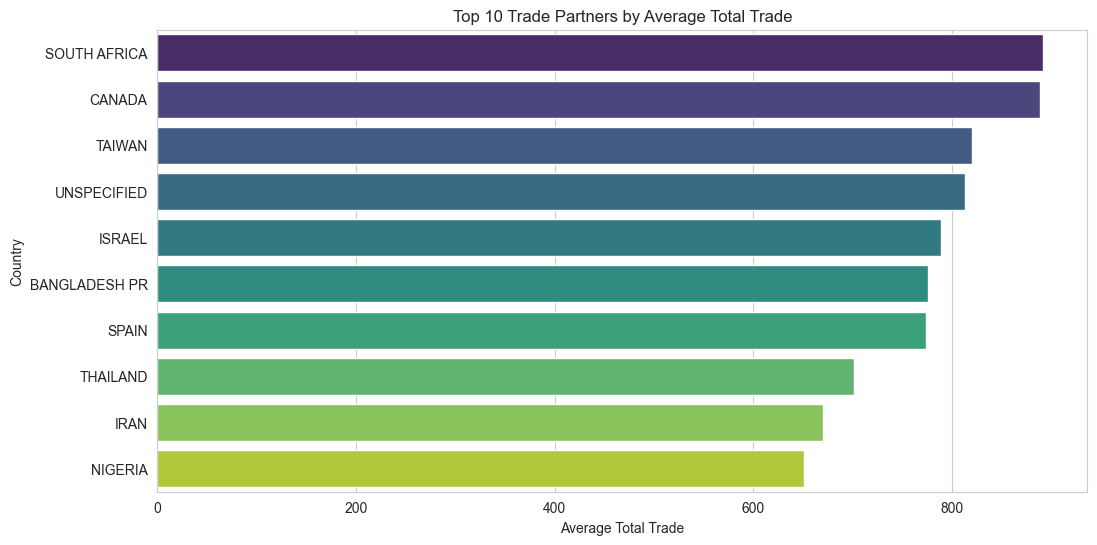

In [79]:
top_trade = (
    df.groupby("Country")["Total Trade"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_trade)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_trade.values,
    y=top_trade.index,
    palette="viridis"
)

plt.title("Top 10 Trade Partners by Average Total Trade")
plt.xlabel("Average Total Trade")
plt.ylabel("Country")

plt.show()

#### Q2. Top 10 Countries with Highest Average Trade Balance

Country
Petroleum Products    939.190000
BANGLADESH PR         804.928000
HONG KONG             553.980000
SRI LANKA DSR         550.386667
SPAIN                 537.577000
NETHERLAND            517.561250
PHILIPPINES           458.743182
MAURITIUS             453.005500
ETHIOPIA              350.818462
ITALY                 347.998636
Name: Trade Balance, dtype: float64


C:\Users\Mayan\AppData\Local\Temp\ipykernel_22532\1520122248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


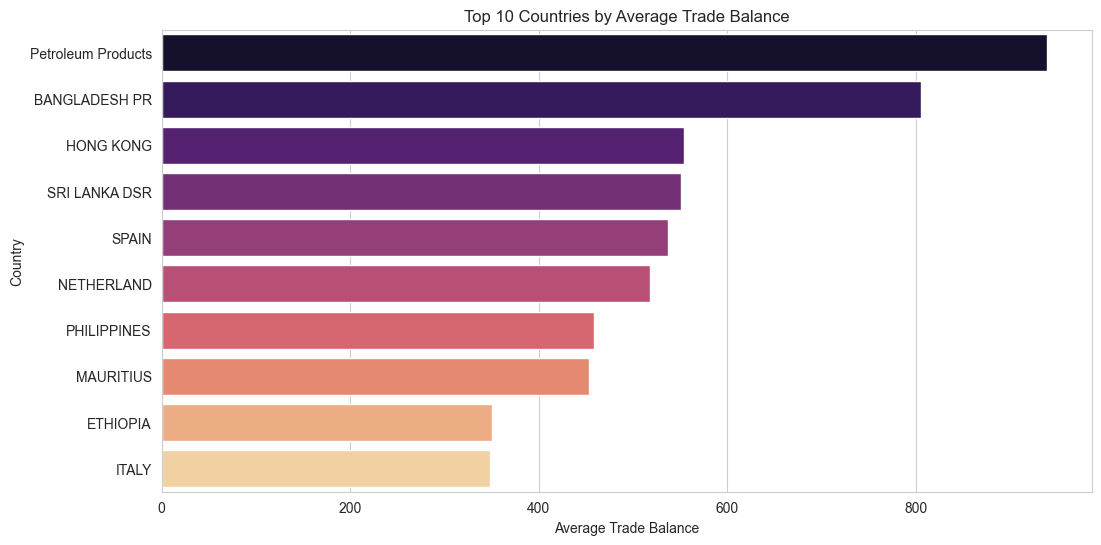

In [80]:
top_balance = (
    df.groupby("Country")["Trade Balance"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_balance)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_balance.values,
    y=top_balance.index,
    palette="magma"
)

plt.title("Top 10 Countries by Average Trade Balance")
plt.xlabel("Average Trade Balance")
plt.ylabel("Country")

plt.show()

#### Q3. Top 10 Trade Partners Based on Average Total Trade

Country
SOUTH AFRICA     891.900000
CANADA           888.696667
TAIWAN           820.394000
UNSPECIFIED      813.420000
ISRAEL           788.722500
BANGLADESH PR    775.870000
SPAIN            774.403333
THAILAND         701.805000
IRAN             670.006667
NIGERIA          651.101667
Name: Total Trade, dtype: float64


C:\Users\Mayan\AppData\Local\Temp\ipykernel_22532\2054702262.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


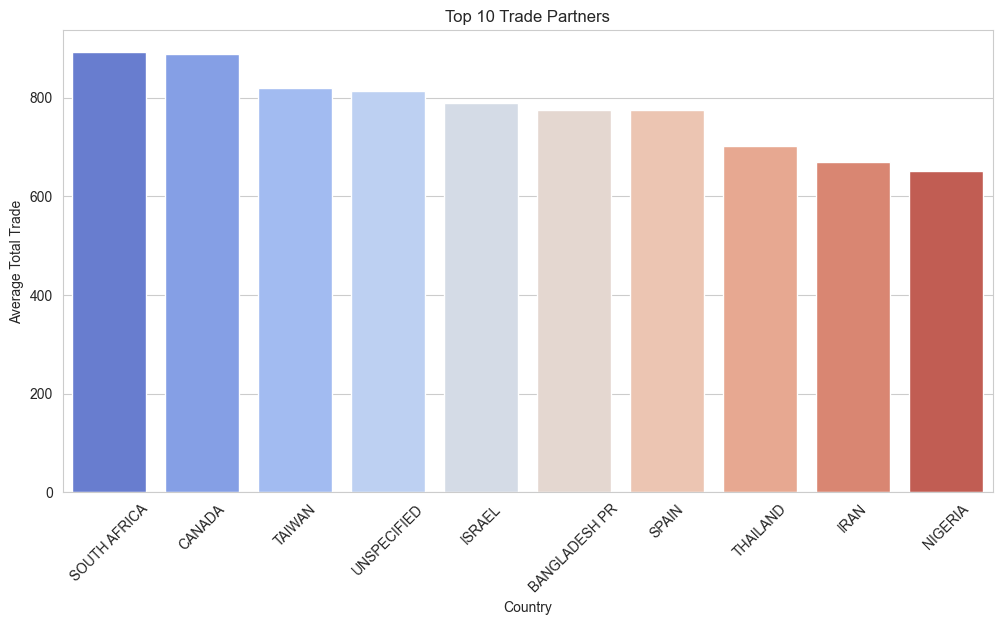

In [81]:
average_trade = (
    df.groupby("Country")["Total Trade"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(average_trade)

plt.figure(figsize=(12,6))

sns.barplot(
    x=average_trade.index,
    y=average_trade.values,
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Top 10 Trade Partners")
plt.xlabel("Country")
plt.ylabel("Average Total Trade")

plt.show()

#### Q4. Line Plot of Total Exports and Imports (1997–2022)

                         Export    Import
Financial Year(start)                    
1997                   16256.63  12913.68
1998                   14568.83  10116.76
1999                   15887.37  11910.60
2000                   18391.01  13715.88
2001                   19296.17  12422.88
2002                   19701.77  13005.88
2003                   19189.98  12852.89
2004                   20856.04  15257.26
2005                   19830.64  16488.85
2006                   23751.57  20643.67
2007                   23496.26  19516.08
2008                   25684.72  17322.68
2009                   25310.91  20352.35
2010                   27212.70  19475.72
2011                   31791.50  20811.33
2012                   26141.53  24606.12
2013                   28901.36  23683.51
2014                   28911.72  24452.61
2015                   29104.02  25763.59
2016                   28540.73  24263.49
2017                   31084.77  27188.73
2018                   31539.79  2

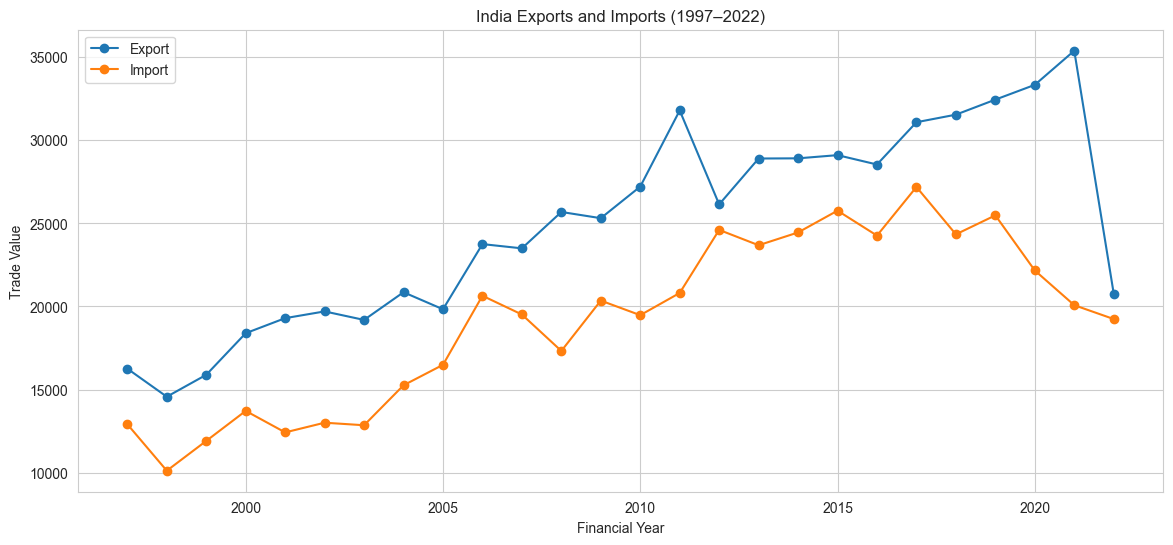

In [82]:
trade = (
    df.groupby("Financial Year(start)")[["Export", "Import"]]
      .sum()
)

print(trade)

plt.figure(figsize=(14,6))

plt.plot(
    trade.index,
    trade["Export"],
    marker="o",
    label="Export"
)

plt.plot(
    trade.index,
    trade["Import"],
    marker="o",
    label="Import"
)

plt.title("India Exports and Imports (1997–2022)")

plt.xlabel("Financial Year")

plt.ylabel("Trade Value")

plt.legend()

plt.grid(True)

plt.show()

#### Q5. Pie Chart of Export Share in 2020

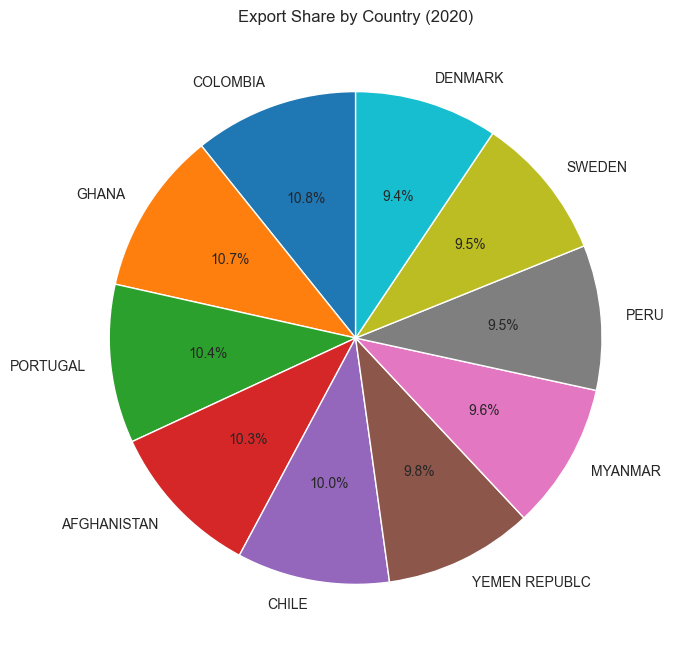

In [83]:
export2020 = df[df["Financial Year(start)"] == 2020]

country_export = (
    export2020.groupby("Country")["Export"]
              .sum()
              .sort_values(ascending=False)
)

# Top 10 countries
top10 = country_export.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Export Share by Country (2020)")

plt.show()